In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from shapely.geometry import Point
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

## Extraction des points de fire pour chaque point de notre grille 

In [2]:
fire_path = "Cleaned_dataset/Fire/cleaned_fire_data.gpkg"
grid_path = "Cleaned_dataset/grid/algeria_tunisia_grid.csv"

fire_df = gpd.read_file(fire_path)
print(fire_df.head())
print(fire_df.info())
print(fire_df.columns)

   latitude  longitude  bright_ti4  scan  track    acq_date confidence  \
0  31.87053    6.17046      297.28  0.46   0.39  2018-04-01          n   
1  32.15597    6.44338      306.38  0.47   0.40  2018-04-01          n   
2  32.18927    6.38575      304.70  0.47   0.39  2018-04-01          n   
3  28.76641    8.92115      297.27  0.48   0.48  2018-04-01          n   
4  28.76545    8.92372      305.55  0.48   0.48  2018-04-01          n   

   bright_ti5       frp daynight  year  time_sin  time_cos   frp_log  \
0      277.23  0.662688        N  2018  0.406737  0.913545  0.508436   
1      281.00  0.850151        N  2018  0.406737  0.913545  0.615267   
2      281.07  0.647103        N  2018  0.406737  0.913545  0.499018   
3      279.18  0.314811        N  2018  0.406737  0.913545  0.273693   
4      278.81  0.631272        N  2018  0.406737  0.913545  0.489360   

                   geometry  
0  POINT (6.17046 31.87053)  
1  POINT (6.44338 32.15597)  
2  POINT (6.38575 32.18927)  
3 

In [3]:
def grid_fire_count_plot(
    grid_csv,
    fire_gpkg,
    metric_crs="EPSG:32631",
    output_grid_csv=None
):
    """
    Count how many fires fall into each grid cell (binary 0/1)
    and preserve the fire year.
    """

    grid_df = pd.read_csv(grid_csv)
    fires_gdf = gpd.read_file(fire_gpkg)

    grid_gdf = gpd.GeoDataFrame(
        grid_df.copy(),
        geometry=gpd.points_from_xy(
            grid_df["longitude"], grid_df["latitude"]
        ),
        crs="EPSG:4326"
    )

    # --- Ensure fires are in WGS84 ---
    if fires_gdf.crs is None:
        fires_gdf.set_crs(epsg=4326, inplace=True)
    else:
        fires_gdf = fires_gdf.to_crs(epsg=4326)

    # --- Extract YEAR (ONLY ADDITION) ---
    fires_gdf["acq_date"] = pd.to_datetime(fires_gdf["acq_date"])
    fires_gdf["year"] = fires_gdf["acq_date"].dt.year

    grid_proj = grid_gdf.to_crs(metric_crs)
    fires_proj = fires_gdf.to_crs(metric_crs)

    # --- KDTree on grid points ---
    grid_coords = np.column_stack([
        grid_proj.geometry.x.values,
        grid_proj.geometry.y.values
    ])
    fire_coords = np.column_stack([
        fires_proj.geometry.x.values,
        fires_proj.geometry.y.values
    ])

    tree = cKDTree(grid_coords)

    # --- Find nearest grid for each fire ---
    _, idxs = tree.query(fire_coords, k=1)

    # --- Binary fire presence ---
    grid_gdf["fire_count"] = 0
    grid_gdf["year"] = 2024

    # Keep first fire per grid cell (no logic change)
    for fire_idx, grid_idx in enumerate(idxs):
        if grid_gdf.loc[grid_idx, "fire_count"] == 0:
            grid_gdf.loc[grid_idx, "fire_count"] = 1
            grid_gdf.loc[grid_idx, "year"] = fires_gdf.iloc[fire_idx]["year"]

    # --- Save CSV if requested ---
    if output_grid_csv:
        grid_gdf[["longitude", "latitude", "fire_count", "year"]] \
            .to_csv(output_grid_csv, index=False)

    # --- Plot ---
    fire_cells = grid_gdf[grid_gdf["fire_count"] > 0]

    fig, ax = plt.subplots(figsize=(12, 8))
    fire_cells.plot(ax=ax, color="red", markersize=5, alpha=0.7)
    ax.set_title("Points de feu détectés sur la grille", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()

    return grid_gdf


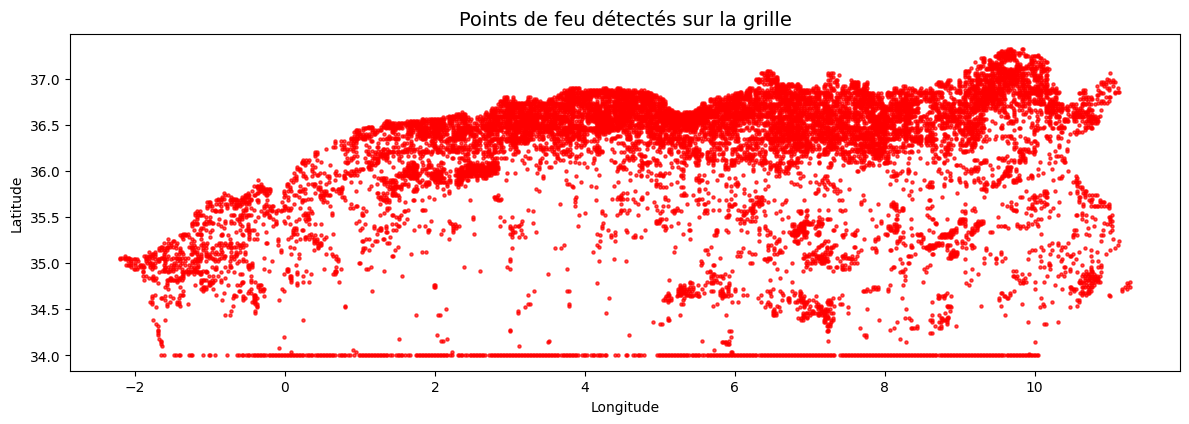

In [4]:
grid_path = "Cleaned_dataset/grid/algeria_tunisia_grid.csv"
fires_path = "Cleaned_dataset/Fire/cleaned_fire_data.gpkg"
output_csv = "Cleaned_dataset/grid/fire_grid.csv"

grid_with_fires = grid_fire_count_plot(
    grid_csv=grid_path,
    fire_gpkg=fires_path,
    output_grid_csv=output_csv
)


In [5]:

print("Number of missing values per column:\n", grid_with_fires.isna().sum())
print(grid_with_fires.shape)

Number of missing values per column:
 longitude     0
latitude      0
geometry      0
fire_count    0
year          0
dtype: int64
(82694, 5)


In [6]:
print("\n================ FIRE_COUNT DISTRIBUTION ================")
print(grid_with_fires['fire_count'].value_counts().sort_index())
print("==========================================================")


================ FIRE_COUNT DISTRIBUTION ================
fire_count
0    69961
1    12733
Name: count, dtype: int64
